# Day 08. Exercise 04
# Regression

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold 
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [2]:
df = pd.read_csv('../data/checker_regression.csv', sep=',')
df.fillna(0, inplace=True)
df.drop_duplicates('uid', inplace=True, keep='last')
df.reset_index(inplace=True)  # inplace = True изменения будут применены к исходному DataFrame
df.drop(columns=['index', 'uid'], inplace = True)
df.head()

,num_commits,pageviews,AVG(diff)
0,62,28.0,0.0
1,20,89.0,0.0
2,7,0.0,-2.0
3,86,0.0,-89.0
4,52,0.0,-48.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 828.0 bytes


In [12]:
X = df[['num_commits','pageviews']]
y = df['AVG(diff)']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

- Перекрестная проверка K-Fold — это метод, при котором набор данных делится на «k» подмножеств (фолдов) для более надежной оценки производительности модели.

- внутри функция cross_validate сама создаёт KFold(n_splits=10), по умолчанию без перемешивания (shuffle=False), но данные режутся просто «по порядку», как идут в таблице.

- KFold — это инструмент, который даёт контроль над тем, как именно разбиваются данные.

In [ ]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21) # shuffle - перемешивание перед разделением
    
    cross = cross_validate(model,
                           X,
                           y,
                           scoring='neg_mean_squared_error',
                           cv=kf,
                           return_train_score=True)
    
    train = np.abs(cross['train_score'])
    test = np.abs(cross['test_score'])
    
    for i in range(n_splits):
        print(f'train -  {train[i]}   |   test -  {test[i]}')
    print(f'Average RMSE on crossval is {test.mean()}')

RMSE = Root Mean Squared Error, корень из средней квадратической ошибки. на сколько в среднем модель ошибается в единицах исходной переменной.

In [18]:
reg = LinearRegression(fit_intercept=False)
crossval(10, X_train, y_train, reg)

train -  3474.6309920473223   |   test -  19646.096588450164
train -  5670.1887470492375   |   test -  5047.952171680795
train -  5665.939791013025   |   test -  7368.921593868307
train -  5787.157264005095   |   test -  9328.64155356211
train -  5506.949506419049   |   test -  5948.246582532382
train -  6025.229716025466   |   test -  576.6626687365267
train -  5739.295354327532   |   test -  3504.6721137554787
train -  5074.979453005715   |   test -  10783.768242300968
train -  5955.673922271466   |   test -  1247.17412199688
train -  5937.012359254541   |   test -  1517.8331448768001
Average RMSE on crossval is 6496.996878176042


In [19]:
regressor = DecisionTreeRegressor(max_depth=4, random_state=21)
crossval(10, X_train, y_train, regressor)

train -  390.33225000000004   |   test -  3995.5200000000004
train -  435.8125   |   test -  6766.396481481483
train -  486.79631944444446   |   test -  132.66750000000005
train -  472.7260714285714   |   test -  74.0138888888889
train -  231.71156966490304   |   test -  6441.125
train -  465.24458994708993   |   test -  231.125
train -  455.7362169312169   |   test -  1647.3800000000003
train -  465.24458994708993   |   test -  1383.125
train -  415.9717923280423   |   test -  949.3903124999995
train -  172.1704232804233   |   test -  4777.53125
Average RMSE on crossval is 2639.827443287037


In [20]:
regr = RandomForestRegressor(n_estimators=100, max_depth = 25, random_state=21)
crossval(10, X_train, y_train, regr)

train -  394.1442250472217   |   test -  5857.890061814804
train -  513.9911699625007   |   test -  6661.487939370374
train -  470.6656164055553   |   test -  32.63097900000011
train -  516.5291838637565   |   test -  84.21994355555576
train -  594.6173277328054   |   test -  4920.604616
train -  396.3249666574072   |   test -  1605.8620625
train -  421.30450639947196   |   test -  3100.6491565555593
train -  498.4444699880948   |   test -  525.3980578888874
train -  359.9379804775133   |   test -  699.4697011249941
train -  278.45742399603176   |   test -  4799.989416499999
Average RMSE on crossval is 2828.8201934310177


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

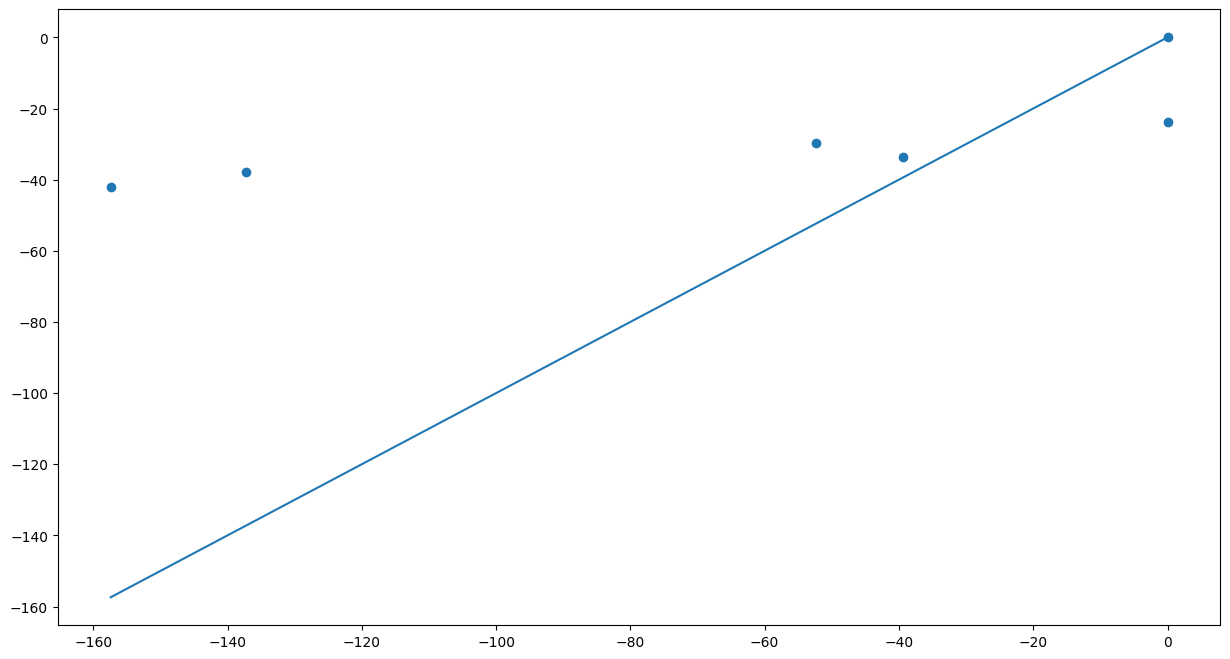

In [26]:
reg.fit(X_train, y_train)
plt.figure(figsize=(15, 8))
plt.scatter(y_test, reg.predict(X_test))
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

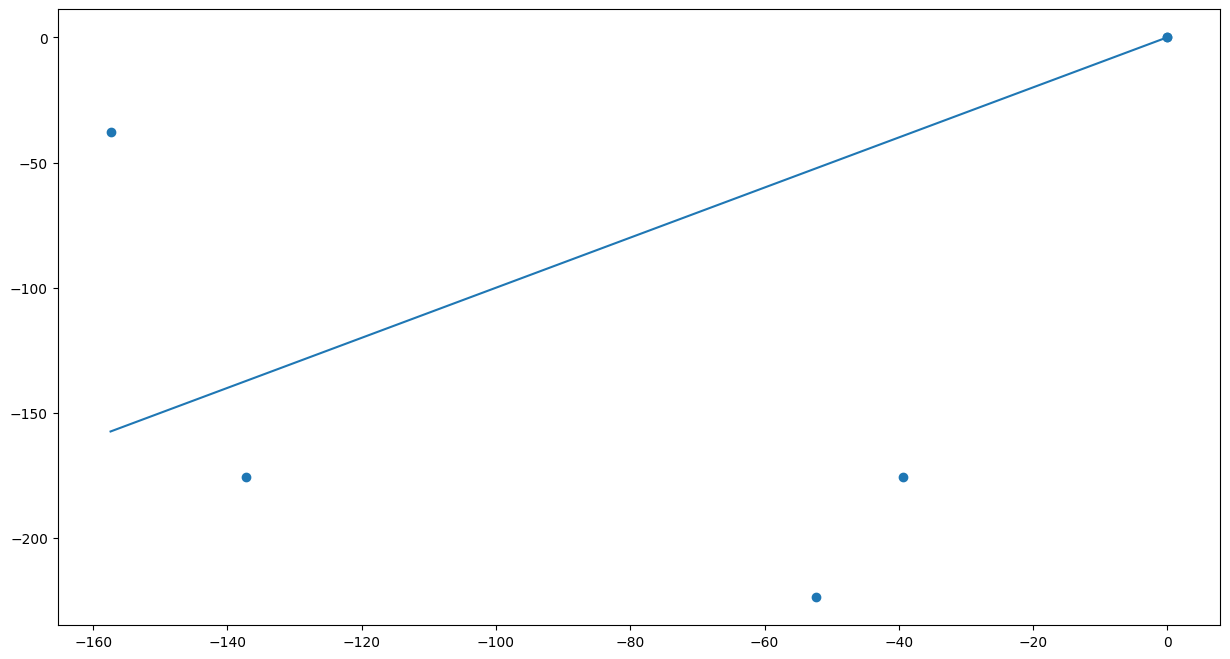

In [27]:
regressor.fit(X_train, y_train)
plt.figure(figsize=(15, 8))
plt.scatter(y_test, regressor.predict(X_test))
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

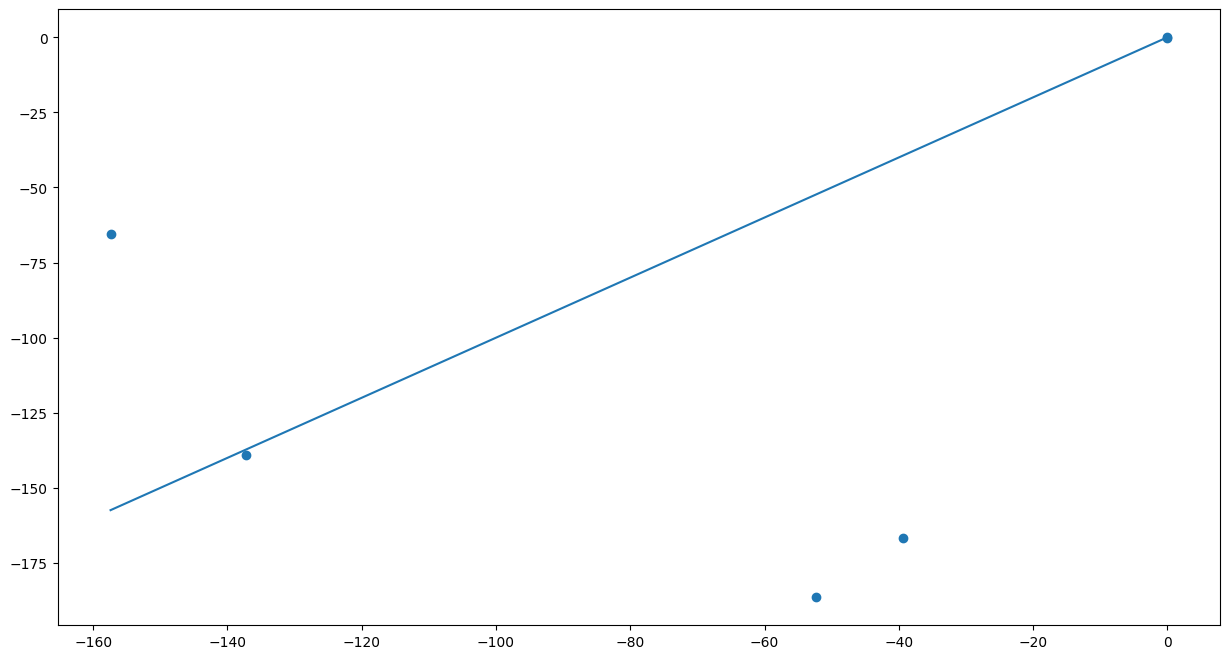

In [28]:
regr.fit(X_train, y_train)
plt.figure(figsize=(15, 8))
plt.scatter(y_test, regr.predict(X_test))
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

### diagonal